# Practice 2 – VGG-16 Transfer Learning trên CIFAR-10

## 1. Mục tiêu

Trong bài thực hành này, chúng ta sử dụng mô hình VGG-16 pretrained
trên ImageNet và áp dụng Transfer Learning cho bài toán phân loại ảnh
CIFAR-10 gồm 10 lớp.

Mục tiêu chính:

- Làm quen với mô hình VGG-16 pretrained.
- Sử dụng Transfer Learning cho bài toán phân loại ảnh.
- Thay đổi classifier để phù hợp với 10 lớp của CIFAR-10.
- Kiểm tra input/output của mô hình.
- Thực nghiệm với hai learning rate:
  - 0.001
  - 0.0001
- So sánh Loss và Accuracy giữa hai learning rate.
- Lưu checkpoint của mô hình tốt nhất.
- Phân tích và rút ra kết luận từ kết quả thực nghiệm.

## 2. Import + Project Path + Device

Phần này thực hiện các thiết lập ban đầu cho notebook, bao gồm:
- Import các thư viện cần thiết.
- Thiết lập Project Path.
- Xác định Device được sử dụng để chạy mô hình.

Các thiết lập này được sử dụng xuyên suốt toàn bộ bài thực hành.

In [9]:
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim

root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from configs.base_config import Config
from src.data import DataConfig, build_dataloaders
from src.models.vgg16 import (
    VGG16Config,
    build_vgg16,
    count_parameters,
    model_size_mb,
    build_summary,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

base_config = Config()
print(base_config)

Device: cpu
Config(project_dir=WindowsPath('C:/Users/THANH THI PC/Desktop/UTH-Deep-Learning-nhom2/Practice_2'), data_dir=WindowsPath('C:/Users/THANH THI PC/Desktop/UTH-Deep-Learning-nhom2/Practice_2/data'), seed=42, num_classes=10, image_size=224, batch_size=32, num_workers=2, val_ratio=0.1)


## 3. DataLoader chung

Trong phần này, dữ liệu CIFAR-10 được tải và chuẩn bị để sử dụng
cho quá trình huấn luyện, validation và testing mô hình VGG-16.

Ảnh đầu vào được resize về kích thước **224 × 224** để phù hợp
với mô hình VGG-16 pretrained.

Sử dụng **Batch Size = 32**.

Dataset CIFAR-10 được sử dụng cho bài toán phân loại với **10 lớp**.
Các DataLoader được sử dụng để cung cấp dữ liệu cho quá trình
training, validation và testing.

In [3]:
data_config = DataConfig(
    data_dir=base_config.data_dir,
    image_size=base_config.image_size,
    batch_size=base_config.batch_size,
    val_ratio=base_config.val_ratio,
    num_workers=base_config.num_workers,
    seed=base_config.seed,
)

data = build_dataloaders(data_config)

train_loader = data["train_loader"]
val_loader = data["val_loader"]
test_loader = data["test_loader"]
class_names = data["class_names"]

print("So luong mau train:", len(data["train_dataset"]))
print("So luong mau validation:", len(data["val_dataset"]))
print("So luong mau test:", len(data["test_dataset"]))
print("Cac lop:", class_names)

So luong mau train: 45000
So luong mau validation: 5000
So luong mau test: 10000
Cac lop: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 4. Giới thiệu VGG16

VGG16 là mô hình Convolutional Neural Network (CNN) được sử dụng
trong bài thực hành để thực hiện bài toán phân loại ảnh.

Trong notebook này, mô hình VGG16 được sử dụng dưới dạng **pretrained model**.
Mô hình đã được huấn luyện trước và được sử dụng để tận dụng các đặc trưng
đã học được trong quá trình huấn luyện.

Kiến trúc VGG16 trong bài gồm hai phần chính:

- **Feature Extractor:** sử dụng các lớp Convolution, ReLU và Max Pooling
  để trích xuất đặc trưng từ hình ảnh.
- **Classifier:** sử dụng các lớp Fully Connected để thực hiện phân loại.

Do bài toán hiện tại sử dụng CIFAR-10 với **10 lớp**, lớp cuối của
Classifier được thay đổi để có **10 output** thay vì số output ban đầu
của mô hình pretrained.

Mục đích của việc sử dụng VGG16 pretrained là áp dụng **Transfer Learning**,
tận dụng các đặc trưng đã được mô hình học trước thay vì huấn luyện
toàn bộ mô hình từ đầu.

In [4]:
from torchvision import models
from torchvision.models import VGG16_Weights

vgg16_raw = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

print("=== Phan FEATURES ===")
print(vgg16_raw.features)

print("\n=== Phan CLASSIFIER (goc, 1000 lop ImageNet) ===")
print(vgg16_raw.classifier)

print("\nLop cuoi (classifier[6]):", vgg16_raw.classifier[6])

=== Phan FEATURES ===
Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv

## 5. Build pretrained VGG16 + Classifier 10 lớp

Trong phần này, mô hình **VGG16 pretrained** được sử dụng làm mô hình
cơ sở cho bài toán phân loại ảnh CIFAR-10.

Mô hình VGG16 pretrained được sử dụng để tận dụng các đặc trưng đã
được học trước đó.

Do bài toán CIFAR-10 có **10 lớp**, lớp cuối của phần Classifier được
điều chỉnh để mô hình có **10 output** phù hợp với bài toán hiện tại.

Sau khi xây dựng mô hình, tiến hành kiểm tra kiến trúc và các tham số
của VGG16 trước khi thực hiện quá trình huấn luyện.

In [5]:
# 1. Khởi tạo cấu hình cho CIFAR-10
config = VGG16Config(num_classes=10)

# 2. Xây dựng mô hình
model = build_vgg16(config)

# 3. In tóm tắt cấu trúc mô hình để kiểm tra
summary = build_summary(model, config)
print(summary)

{'num_classes': 10, 'freeze_features': True, 'learning_rate': 0.001, 'total_params': 134301514, 'trainable_params': 119586826, 'model_size_mb': 512.32}


## 6. Parameter + Forward Check

Trong phần này, tiến hành kiểm tra các thông số chính của mô hình
và thực hiện Forward Pass để kiểm tra kích thước đầu vào, nhãn và
đầu ra của mô hình.

Các thông tin được kiểm tra gồm:

- Số lượng lớp phân loại: **10**
- Feature Extractor được đóng băng: **True**
- Learning Rate: **0.001**
- Tổng số tham số: **134,301,514**
- Số tham số có thể train: **119,586,826**
- Dung lượng model ước tính: **512.32 MB**

### Forward Check

Thực hiện Forward Pass với một batch dữ liệu để kiểm tra kích thước
tensor đầu vào, nhãn và đầu ra của mô hình.

Kết quả:

- Input shape: **[32, 3, 224, 224]**
- Labels shape: **[32]**
- Output shape: **[32, 10]**

Trong đó, batch size là **32**, đầu vào gồm **3 kênh màu** với kích thước
**224 × 224**. Mô hình tạo ra output có kích thước **[32, 10]**.

In [6]:
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

# Instantiate VGG config and model (was missing)
vgg_config = VGG16Config(
    num_classes=base_config.num_classes,
    freeze_features=True,
    learning_rate=0.001,  # use default LR since base_config has no learning_rate
)
model = build_vgg16(vgg_config).to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)

print("Input shape:", images.shape)
print("Labels shape:", labels.shape)
print("Output shape:", outputs.shape)  # ky vong: [batch_size, 10]

Input shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Output shape: torch.Size([32, 10])


In [7]:
summary = build_summary(model, vgg_config)

for key, value in summary.items():
    print(f"{key}: {value}")

num_classes: 10
freeze_features: True
learning_rate: 0.001
total_params: 134301514
trainable_params: 119586826
model_size_mb: 512.32


## 7. Thiết kế thí nghiệm Learning Rate

Trong phần này, tiến hành thực nghiệm để đánh giá ảnh hưởng của
**Learning Rate** đến kết quả huấn luyện mô hình VGG16.

Thực hiện hai cấu hình với Learning Rate khác nhau:

- **Experiment 1:** Learning Rate = **0.001**
- **Experiment 2:** Learning Rate = **0.0001**

Các điều kiện khác của quá trình huấn luyện được giữ nguyên để có thể
so sánh kết quả giữa hai Learning Rate.

Mỗi cấu hình được huấn luyện trong **10 epochs** 

Mục tiêu của thí nghiệm là so sánh kết quả **Training Loss, Validation Loss,
Training Accuracy và Validation Accuracy**, từ đó lựa chọn Learning Rate
phù hợp hơn cho mô hình.

## 8. Thực nghiệm với hai Learning Rate

Trong phần này, tiến hành thực nghiệm mô hình với hai giá trị
Learning Rate khác nhau:

- **Learning Rate = 0.001**
- **Learning Rate = 0.0001**

Các điều kiện khác của quá trình huấn luyện được giữ nguyên để đảm bảo
có thể so sánh ảnh hưởng của Learning Rate đến kết quả mô hình.

Hai thí nghiệm được thực hiện trong cùng một cell code. Kết quả huấn luyện
được sử dụng để so sánh hiệu quả của hai cấu hình Learning Rate.

Kết quả thu được:

- **LR = 0.001:** Best Validation Accuracy = **87.44%**
- **LR = 0.0001:** Best Validation Accuracy = **89.20%**

Learning Rate = **0.0001** cho kết quả Validation Accuracy cao hơn
so với Learning Rate = **0.001**.

In [ ]:
import time
from Practice_2.src.trainer import train_model

results = {}

for lr in [0.001, 0.0001]:
    exp_name = f"vgg16_lr_{lr}"
    print(f"\n===== Bắt đầu thí nghiệm: {exp_name} =====")

    exp_config = VGG16Config(
        num_classes=base_config.num_classes,
        freeze_features=True,
        learning_rate=lr,
    )
    exp_model = build_vgg16(exp_config)

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, exp_model.parameters()),
        lr=lr,
    )
    criterion = nn.CrossEntropyLoss()

    start_time = time.time()

    history = train_model(
        model=exp_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=10,
        log_dir=f"../runs/vgg16/{exp_name}",
        checkpoint_path=f"../checkpoints/{exp_name}_best.pth",
    )

    training_time = time.time() - start_time

    results[exp_name] = {
        "history": history,
        "training_time_sec": round(training_time, 1),
        "best_val_acc": max(history["val_acc"]),
    }

    print(f"===== Xong {exp_name} — thời gian: {training_time:.1f}s — "
        f"best val acc: {max(history['val_acc']):.2f}% =====")

for name, r in results.items(): 
    print(f"{name}: best_val_acc={r['best_val_acc']:.2f}%, "
        f"training_time={r['training_time_sec']}s")


===== Bắt đầu thí nghiệm: vgg16_lr_0.001 =====

Epoch [1/10]


Validating: 100%|██████████| 157/157 [09:53<00:00,  3.78s/it]


Train Loss: 1.2002, Train Acc: 62.46%
Val Loss: 0.5934, Val Acc: 81.64%
Validation accuracy improved (0.00% --> 81.64%). Saving model...

Epoch [2/10]


Validating: 100%|██████████| 157/157 [09:58<00:00,  3.82s/it]


Train Loss: 0.9785, Train Acc: 69.60%
Val Loss: 0.5084, Val Acc: 83.60%
Validation accuracy improved (81.64% --> 83.60%). Saving model...

Epoch [3/10]


...

Train Loss: 0.3597, Train Acc: 87.35%
Val Loss: 0.3396, Val Acc: 89.04%

Epoch [9/10]


Validating: 100%|██████████| 157/157 [06:55<00:00,  2.65s/it]


Train Loss: 0.3454, Train Acc: 87.98%
Val Loss: 0.3529, Val Acc: 89.10%

Epoch [10/10]


Validating: 100%|██████████| 157/157 [10:09<00:00,  3.88s/it]


Train Loss: 0.3325, Train Acc: 88.46%
Val Loss: 0.3431, Val Acc: 89.20%
Validation accuracy improved (89.10% --> 89.20%). Saving model...
===== Xong vgg16_lr_0.0001 — thời gian: 52018.1s — best val acc: 89.20% =====
vgg16_lr_0.001: best_val_acc=87.44%, training_time=55102.2s
vgg16_lr_0.0001: best_val_acc=89.20%, training_time=52018.1s


## 9. Bảng so sánh

Bảng dưới đây tổng hợp kết quả của hai thí nghiệm Learning Rate.
Các điều kiện khác được giữ nguyên để so sánh ảnh hưởng của Learning Rate
đến kết quả Validation Accuracy.

| Learning Rate | Best Validation Accuracy |
|---------------|--------------------------|
| **0.001**     | **87.44%**               |
| **0.0001**    | **89.20%**               |

### Nhận xét

Learning Rate **0.0001** đạt Best Validation Accuracy **89.20%**,
cao hơn Learning Rate **0.001** với kết quả **87.44%**.

Chênh lệch giữa hai cấu hình là **1.76 điểm phần trăm**.
Trong hai cấu hình được thử nghiệm, **Learning Rate = 0.0001**
cho kết quả Validation Accuracy tốt hơn.

## 10. Biểu đồ so sánh Learning Rate

Các biểu đồ dưới đây trực quan hóa quá trình huấn luyện VGG-16 với hai
Learning Rate là **0.001** và **0.0001** qua 10 epochs.

### Biểu đồ Loss

Biểu đồ so sánh **Training Loss** và **Validation Loss** của hai cấu hình
Learning Rate theo từng epoch. Qua đó có thể theo dõi sự thay đổi của
Loss trong quá trình huấn luyện.

### Biểu đồ Accuracy

Biểu đồ so sánh **Training Accuracy** và **Validation Accuracy** của hai
cấu hình Learning Rate theo từng epoch.

Kết quả cho thấy cấu hình **Learning Rate = 0.0001** đạt Validation Accuracy
cao hơn so với **Learning Rate = 0.001**, với Best Validation Accuracy
lần lượt là **89.20%** và **87.44%**.

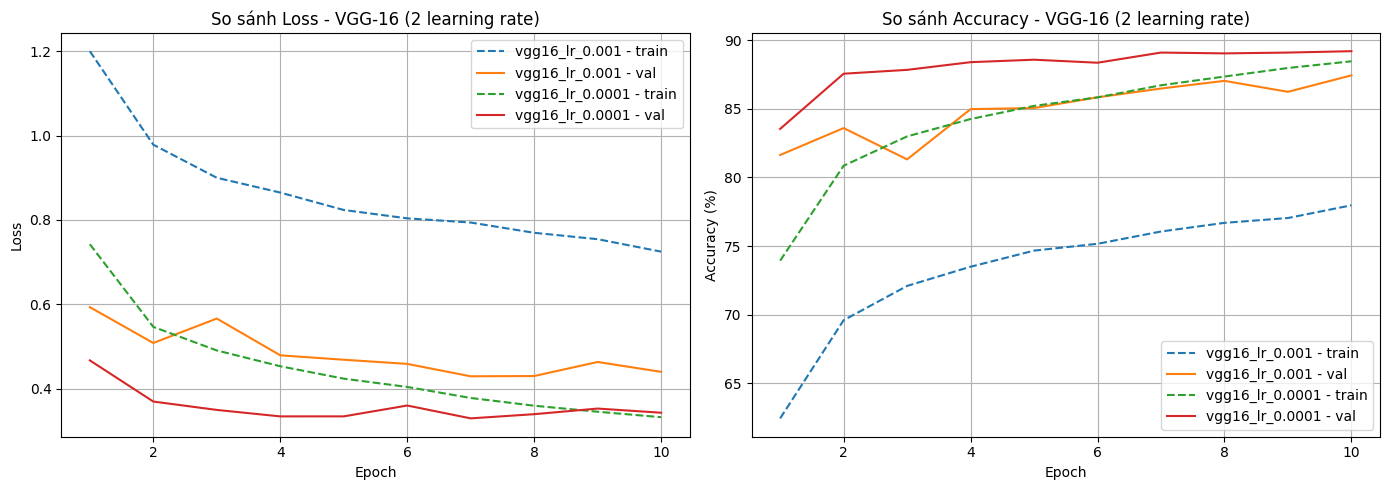

Đã lưu biểu đồ tại: ..\results\figures\vgg16_lr_comparison.png


In [17]:
import matplotlib.pyplot as plt
from pathlib import Path

figures_dir = Path("../results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Biểu đồ Loss ---
for exp_name, r in results.items():
    epochs = range(1, len(r["history"]["train_loss"]) + 1)
    axes[0].plot(epochs, r["history"]["train_loss"], linestyle="--", label=f"{exp_name} - train")
    axes[0].plot(epochs, r["history"]["val_loss"], linestyle="-", label=f"{exp_name} - val")

axes[0].set_title("So sánh Loss - VGG-16 (2 learning rate)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# --- Biểu đồ Accuracy ---
for exp_name, r in results.items():
    epochs = range(1, len(r["history"]["train_acc"]) + 1)
    axes[1].plot(epochs, r["history"]["train_acc"], linestyle="--", label=f"{exp_name} - train")
    axes[1].plot(epochs, r["history"]["val_acc"], linestyle="-", label=f"{exp_name} - val")

axes[1].set_title("So sánh Accuracy - VGG-16 (2 learning rate)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(figures_dir / "vgg16_lr_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Đã lưu biểu đồ tại: {figures_dir / 'vgg16_lr_comparison.png'}")

## 11. Checkpoint Local

Sau khi hoàn thành quá trình huấn luyện, tiến hành kiểm tra các
checkpoint đã được lưu cho từng thí nghiệm Learning Rate.

Checkpoint được lưu lại nhằm giữ trạng thái và trọng số của mô hình
sau quá trình huấn luyện. Từ các checkpoint của hai thí nghiệm, tiến hành
xác định checkpoint có kết quả Validation Accuracy tốt nhất.

Kết quả kiểm tra:

- **LR = 0.001:** checkpoint đã được lưu, dung lượng khoảng **1424.7 MB**
- **LR = 0.0001:** checkpoint đã được lưu, dung lượng khoảng **1424.7 MB**

So sánh kết quả giữa hai thí nghiệm cho thấy:

- **LR = 0.001:** Best Validation Accuracy = **87.44%**
- **LR = 0.0001:** Best Validation Accuracy = **89.20%**

Do đó, checkpoint tốt nhất là checkpoint của **LR = 0.0001**, với
Best Validation Accuracy đạt **89.20%**.

Checkpoint này được lựa chọn để sử dụng cho các bước phân tích tiếp theo.

In [10]:
from pathlib import Path

checkpoints_dir = root_dir / "checkpoints"

print("Checkpoint được lưu local và không được commit lên GitHub.\n")

if "results" in globals():

    for exp_name in results.keys():
        checkpoint_path = (
            checkpoints_dir / f"{exp_name}_best.pth"
        )

        if checkpoint_path.exists():
            size_mb = (
                checkpoint_path.stat().st_size
                / (1024 ** 2)
            )

            print(
                f"✔ {exp_name}: "
                f"{checkpoint_path.name} "
                f"({size_mb:.1f} MB)"
            )

        else:
            print(
                f"ℹ {exp_name}: "
                "checkpoint không có trên máy này "
                "(file .pth được Git ignore)"
            )

else:
    print(
        "ℹ Chưa có biến results trong phiên làm việc hiện tại."
    )
    print(
        "Kết quả training đã được lưu trong output notebook."
    )

Checkpoint được lưu local và không được commit lên GitHub.

ℹ Chưa có biến results trong phiên làm việc hiện tại.
Kết quả training đã được lưu trong output notebook.


## 12. Phân tích

Dựa trên kết quả huấn luyện và hai biểu đồ Loss, Accuracy của hai cấu hình
Learning Rate, có thể đưa ra các nhận xét sau.

### 12.1. Phân tích Loss

Đối với **Learning Rate = 0.001**, Training Loss có xu hướng giảm qua các
epoch, cho thấy mô hình đang học được các đặc trưng từ dữ liệu. Validation
Loss cũng giảm và duy trì ở mức tương đối ổn định về cuối quá trình huấn luyện.

Đối với **Learning Rate = 0.0001**, Training Loss giảm rõ rệt qua các epoch
và Validation Loss cũng giảm theo. Đường Validation Loss về cuối đạt mức
thấp hơn so với cấu hình Learning Rate = 0.001.

Kết quả này cho thấy Learning Rate = 0.0001 giúp quá trình tối ưu diễn ra
ổn định hơn trong thí nghiệm hiện tại.

### 12.2. Phân tích Accuracy

Với **Learning Rate = 0.001**, Validation Accuracy tăng trong quá trình
huấn luyện và đạt Best Validation Accuracy là **87.44%**.

Với **Learning Rate = 0.0001**, Validation Accuracy tăng tốt hơn và đạt
Best Validation Accuracy là **89.20%**.

So sánh hai cấu hình cho thấy Learning Rate = 0.0001 đạt kết quả
Validation Accuracy cao hơn **1.76 điểm phần trăm** so với Learning Rate
= 0.001.

### 12.3. So sánh hai Learning Rate

Kết quả thực nghiệm cho thấy việc lựa chọn Learning Rate có ảnh hưởng
đến khả năng hội tụ và kết quả của mô hình.

- **LR = 0.001:** Best Validation Accuracy = **87.44%**
- **LR = 0.0001:** Best Validation Accuracy = **89.20%**

Trong phạm vi thí nghiệm này, **Learning Rate = 0.0001** cho kết quả tốt
hơn. Đây cũng là cấu hình được lựa chọn để lưu checkpoint tốt nhất.

### 12.4. Nhận xét chung

Thông qua Loss và Accuracy theo từng epoch, có thể thấy cả hai cấu hình
đều giúp mô hình cải thiện kết quả trong quá trình huấn luyện. Tuy nhiên,
cấu hình **Learning Rate = 0.0001** cho Validation Accuracy cao hơn và
Validation Loss có xu hướng thấp hơn ở giai đoạn cuối.

Vì vậy, dựa trên các kết quả thực nghiệm hiện có, **Learning Rate = 0.0001
là lựa chọn phù hợp hơn** cho mô hình VGG16 trong bài toán phân loại
CIFAR-10.

## 13. Kết luận

Trong bài thực nghiệm này, mô hình **VGG16 pretrained** được sử dụng cho
bài toán phân loại ảnh **CIFAR-10 gồm 10 lớp**. Dữ liệu được đưa về kích
thước **224 × 224** để phù hợp với đầu vào của VGG16.

Sau khi xây dựng mô hình và thực hiện Forward Check, kết quả cho thấy
mô hình nhận đầu vào có kích thước **[32, 3, 224, 224]** và tạo ra
đầu ra có kích thước **[32, 10]**, phù hợp với bài toán phân loại 10 lớp.

Hai giá trị Learning Rate là **0.001** và **0.0001** được sử dụng để
thực nghiệm và so sánh. Kết quả cho thấy:

- **LR = 0.001:** Best Validation Accuracy = **87.44%**
- **LR = 0.0001:** Best Validation Accuracy = **89.20%**

Learning Rate **0.0001** cho kết quả tốt hơn **1.76 điểm phần trăm** so
với Learning Rate **0.001**. Đồng thời, checkpoint có kết quả tốt nhất
được xác định là checkpoint của **LR = 0.0001**.

Qua quá trình thực nghiệm, có thể thấy việc lựa chọn Learning Rate có
ảnh hưởng đến quá trình huấn luyện và kết quả Validation Accuracy của
mô hình. Với các điều kiện thí nghiệm đã thực hiện, **LR = 0.0001** là
cấu hình cho kết quả tốt hơn và được lựa chọn làm kết quả cuối cùng.